<a href="https://colab.research.google.com/github/tort-cam/ST554HW6/blob/main/ST554HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ST554 Homework 6
Author: Cameron Mullaney

For this assignment, I will:
* do some SQL practice using the MLB data from a sqlite database
* create a class and a variety of class functions

##Part I
More practice querying a database \
This is pretty similar to last week's homework, I spend some more time working with the MLB data through SQLite3

#####1 - Connect to database

In [1]:
import pandas as pd
import sqlite3
## I've uploaded the sqlite file to my Google Drive
%cd /content/drive/MyDrive/Colab_Notebooks/Colab_data
con = sqlite3.connect("lahman_1871-2022.sqlite")

/content/drive/MyDrive/Colab_Notebooks/Colab_data


In [2]:
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''
data = pd.read_sql(get_schema, con)
data

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


Yep! Same tables as last week!

#####2 - HOF Pitcher Stats

Here I am taking a list of Hall of Famers and a list of every pitcher ever, and using an `INNER JOIN` to create a list only of players who appear on both lists.

In [5]:
get_HOFp = '''
    SELECT hof.playerID, SUM(p.GS), SUM(p.G), SUM(p.W), SUM(p.L), SUM(p.IPOuts), SUM(p.CG), SUM(p.SHO), SUM(p.SV)
    FROM HallOfFame AS hof
    INNER JOIN Pitching AS p ON hof.playerID = p.playerID
    WHERE hof.inducted = "Y" AND p.playerID IS NOT NULL
    GROUP BY p.playerID
    '''

HOFp = pd.read_sql(get_HOFp, con)
HOFp

,playerID,SUM(p.GS),SUM(p.G),SUM(p.W),SUM(p.L),SUM(p.IPOuts),SUM(p.CG),SUM(p.SHO),SUM(p.SV)
0,alexape01,599,696,373,208,15570,437,90,32
1,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,1,1,0,1,12,0,0,0
3,bendech01,334,459,212,127,9051,255,40,34
4,blylebe01,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11
104,wrighge01,0,3,0,1,15,0,0,0
105,wrighha01,8,36,4,4,301,0,0,14
106,wynnea01,612,691,300,244,13692,290,49,15


With 86 Hall of Fame pitchers, a list of 108 sounds about right - ~20 seems like a reasonable number of position players to have thrown an inning or two.

##### 3 - HOF Pitcher Batting

Here, I'm taking the final list of playerIDs from 2, and pulling in their batting stats.

In [147]:
get_HOFpb = '''
    SELECT hof.playerID, SUM(b.AB), SUM(b.R), SUM(b.H), SUM(b.HR), SUM(b.RBI), SUM(b.BB), SUM(b.SO)
    FROM HallOfFame AS hof
    INNER JOIN Batting AS b ON hof.playerID = b.playerID
    WHERE hof.inducted = "Y"
      AND hof.playerID IN (SELECT playerID FROM Pitching)

    GROUP BY b.playerID
    '''

HOFpb = pd.read_sql(get_HOFpb, con)
HOFpb

,playerID,SUM(b.AB),SUM(b.R),SUM(b.H),SUM(b.HR),SUM(b.RBI),SUM(b.BB),SUM(b.SO)
0,alexape01,1810,154,378,11,163,77,276
1,ansonca01,10281,1999,3435,97,2075,984,330
2,becklja01,9551,1603,2938,87,1581,616,526
3,bendech01,1147,102,243,6,116,75,143
4,blylebe01,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...
103,willivi01,1493,107,248,1,84,81,199
104,wrighge01,2873,665,866,11,326,68,119
105,wrighha01,813,183,224,4,113,37,14
106,wynnea01,1704,136,365,17,173,141,330


This list is the same 108 people and their career batting stats.

##### 4 - Table Combo

Here, I'm just combining the two tables from questions 2 & 3.

In [148]:
combo = HOFp.merge(HOFpb, on = "playerID")
combo

,playerID,SUM(p.GS),SUM(p.G),SUM(p.W),SUM(p.L),SUM(p.IPOuts),SUM(p.CG),SUM(p.SHO),SUM(p.SV),SUM(b.AB),SUM(b.R),SUM(b.H),SUM(b.HR),SUM(b.RBI),SUM(b.BB),SUM(b.SO)
0,alexape01,599,696,373,208,15570,437,90,32,1810,154,378,11,163,77,276
1,ansonca01,0,3,0,1,12,0,0,1,10281,1999,3435,97,2075,984,330
2,becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581,616,526
3,bendech01,334,459,212,127,9051,255,40,34,1147,102,243,6,116,75,143
4,blylebe01,685,692,287,250,14910,242,60,0,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11,1493,107,248,1,84,81,199
104,wrighge01,0,3,0,1,15,0,0,0,2873,665,866,11,326,68,119
105,wrighha01,8,36,4,4,301,0,0,14,813,183,224,4,113,37,14
106,wynnea01,612,691,300,244,13692,290,49,15,1704,136,365,17,173,141,330


Yep! 108 rows, now with 16 columns of data.

##Part II - Classes

In this section, I will be:
* Creating a class
* Initializing the attributes of said class
* Creating methods to be used on the class
* Testing these methods to ensure proper function

In [107]:
## Importing what we'll need
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from sklearn import linear_model
import seaborn as sns
import statistics

#####1 - Class Creation

In [121]:
## Creating the class

class SLR_slope_simulator:

    def __init__(self, beta_0, x, beta_1, sigma, seed):
      self.beta_0 = beta_0
      self.beta_1 = beta_1
      self.x = x
      self.n = len(self.x)
      self.sigma = sigma
      self.rng = default_rng(seed)
      self.slopes = []
      self.lm = linear_model.LinearRegression()

    def generate_data(self):
      self.y = self.beta_0 + self.beta_1*self.x + self.rng.standard_normal(self.n)*self.sigma
      return self.x, self.y

    def fit_slope(self, x,y):
      self.lm.fit(x.reshape(-1,1), y)
      return self.lm.coef_[0]

    def run_simulations(self, n):
      for i in range(0,n):
        self.slopes.append(
            self.fit_slope(self.generate_data()[0], self.generate_data()[1])
        )

    def plot_sampling_distribution(self):
      if len(self.slopes) > 0:
          sns.histplot(self.slopes, binwidth = .025)
      else :
        print("Before creating a graph, run_simulations must be called")

    def find_prob(self, value, sided):
      if len(self.slopes) > 0 :
        if sided == "above":
          term = ">"
          slopes_sub = [x for x in self.slopes if x > value]
          print("Estimated probability of sample slope",
                term,value, ":\t", len(slopes_sub)/len(self.slopes))
        elif sided == "below":
          term = "<"
          slopes_sub = [x for x in self.slopes if x < value]
          print("Estimated probability of sample slope",
                term,value,":\t", len(slopes_sub)/len(self.slopes))
        elif sided == "two-sided":
          if value > statistics.median(self.slopes):
            slopes_sub = [x for x in self.slopes if x > value]
          elif value < statistics.median(self.slopes):
            slopes_sub = [x for x in self.slopes if x < value]
          print("Estimated probability of sample slope further from median than", value, ":\t",
                (2*len(slopes_sub)/len(self.slopes)))

#####2 - HW Doc Testing

In [130]:
last = SLR_slope_simulator(
    beta_0 = 12,
    beta_1 = 2,
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3),
    sigma = 1,
    seed = 10
    )

In [131]:
last.plot_sampling_distribution()

Before creating a graph, run_simulations must be called


In [132]:
last.run_simulations(10000)
print(len(last.slopes), sum(last.slopes)/len(last.slopes))

10000 2.0001400732869836


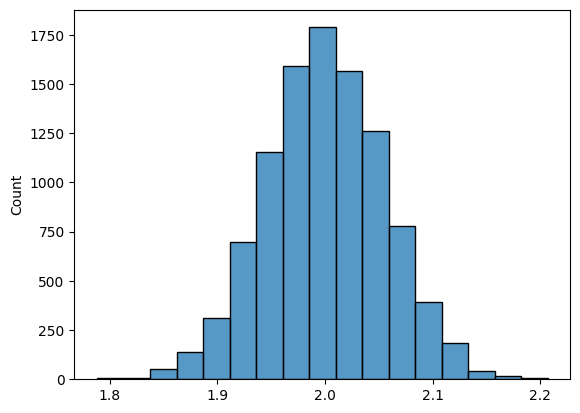

In [133]:
last.plot_sampling_distribution()

In [134]:
last.find_prob(2.1, "two-sided")

Estimated probability of sample slope further from median than 2.1 :	 0.0726


In [137]:
last.slopes

[np.float64(1.9956055116302724),
 np.float64(1.964896413380284),
 np.float64(1.9862612119146508),
 np.float64(2.08981268148745),
 np.float64(1.9117993672267974),
 np.float64(2.008456465741332),
 np.float64(2.0474343500666654),
 np.float64(2.1036180116113665),
 np.float64(1.9193031597528145),
 np.float64(1.9593570244113567),
 np.float64(2.0968216022658095),
 np.float64(1.945219930956409),
 np.float64(2.0190264430482796),
 np.float64(2.0718722108435843),
 np.float64(2.055286387575782),
 np.float64(2.028019933577373),
 np.float64(2.0534761423391066),
 np.float64(2.025676155596352),
 np.float64(2.0209512611859886),
 np.float64(2.1244028833262685),
 np.float64(1.9791296574496051),
 np.float64(1.9796068897678778),
 np.float64(2.010531333975038),
 np.float64(2.020293941503807),
 np.float64(1.97354070174742),
 np.float64(1.949889521855006),
 np.float64(1.8618257136998932),
 np.float64(1.9707427032586888),
 np.float64(2.033226796907173),
 np.float64(2.0117344269000665),
 np.float64(1.9778734359

In [151]:
np.round(statistics.mean(last.slopes),4)

np.float64(2.0001)